In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from jaxtyping import Float
from transformer_lens import HookedTransformer, HookedTransformerConfig

from muutils.dbg import dbg_tensor
from muutils.tensor_info import array_summary

In [ ]:
model_trained = HookedTransformer.from_pretrained("gpt2-small")
model_cfg = model_trained.cfg

# randomize the weights of model
model = HookedTransformer(HookedTransformerConfig.from_dict(model_cfg.to_dict()))

state_dict = model.state_dict()

for k, tensor in state_dict.items():
	if tensor.isnan().any():
		# set the tensor to random gaussian
		print(f"replacing {k} with random tensor")
		state_dict[k] = torch.randn_like(tensor)

model.load_state_dict(state_dict)

for k, tensor in model.state_dict().items():
	if tensor.isnan().any():
		# set the tensor to random gaussian
		print(f"{k} still has nans")

In [ ]:
logits, cache = model.run_with_cache(
	"tial idea was to create something where humanity tried to evolve to a next level but had some kind of foe trying to stop them from doing so. I kind of had this image of human souls fly"
)

In [ ]:
fig, ax = plt.subplots(
	ncols=model_cfg.n_heads, nrows=model_cfg.n_layers, figsize=(50, 50)
)

for layer in range(model_cfg.n_layers):
	for head in range(model_cfg.n_heads):
		# ax[layer, head].matshow(cache[f"blocks.{layer}.attn.hook_attn_scores"][0, head].cpu().numpy())
		# with colorbar
		im = ax[layer, head].imshow(
			cache[f"blocks.{layer}.attn.hook_pattern"][0, head].cpu().numpy()
		)
		fig.colorbar(im, ax=ax[layer, head])

[ <ipykernel>:47 ] A_raw: μ=0.00 σ=0.58 x̃=0.00 R=[-3.12,4.01] ℙ=|  ▃█   | shape=(50,50) dtype=float64
[ <ipykernel>:49 ] A: μ=0.02 σ=0.04 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(50,50) dtype=float64


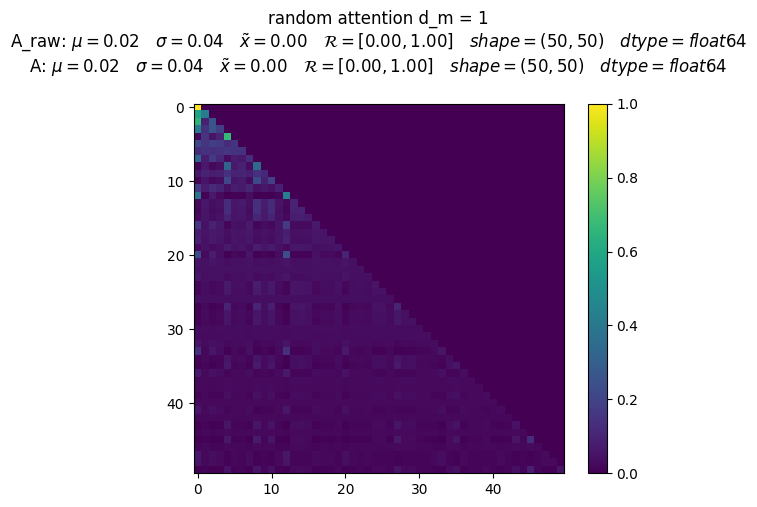

[ <ipykernel>:47 ] A_raw: μ=0.01 σ=3.13 x̃=-0.00 R=[-21.54,18.23] ℙ=|   █▂  | shape=(50,50) dtype=float64
[ <ipykernel>:49 ] A: μ=0.02 σ=0.09 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(50,50) dtype=float64


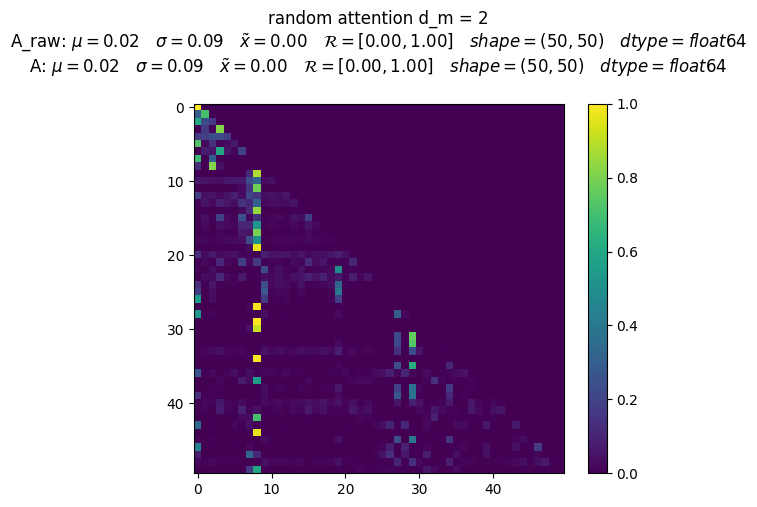

[ <ipykernel>:47 ] A_raw: μ=-0.02 σ=3.31 x̃=-0.00 R=[-15.00,16.42] ℙ=|  ▃█▁  | shape=(50,50) dtype=float64
[ <ipykernel>:49 ] A: μ=0.02 σ=0.09 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(50,50) dtype=float64


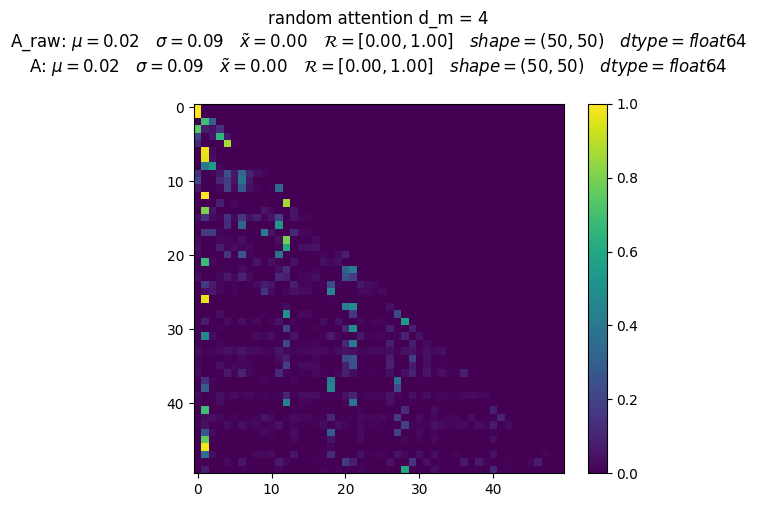

[ <ipykernel>:47 ] A_raw: μ=-0.15 σ=11.00 x̃=-0.04 R=[-62.36,69.64] ℙ=|  ▁█   | shape=(50,50) dtype=float64
[ <ipykernel>:49 ] A: μ=0.02 σ=0.11 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(50,50) dtype=float64


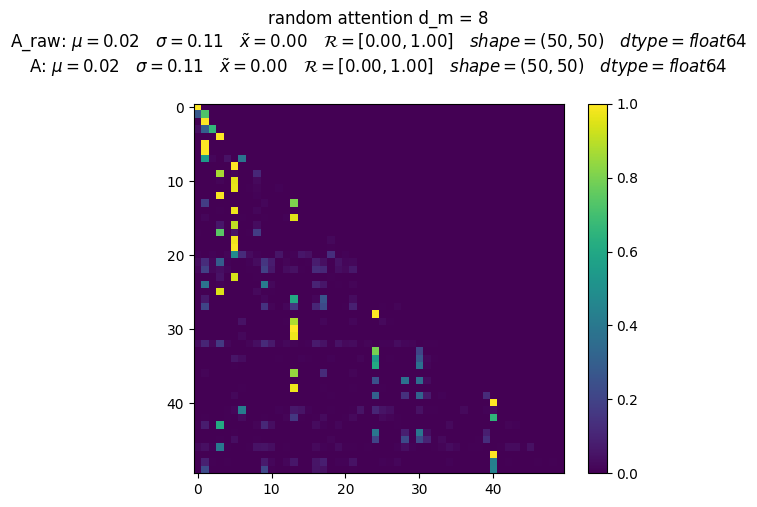

[ <ipykernel>:47 ] A_raw: μ=0.49 σ=19.27 x̃=0.29 R=[-135.91,139.55] ℙ=|  ▁█▁  | shape=(50,50) dtype=float64
[ <ipykernel>:49 ] A: μ=0.02 σ=0.13 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(50,50) dtype=float64


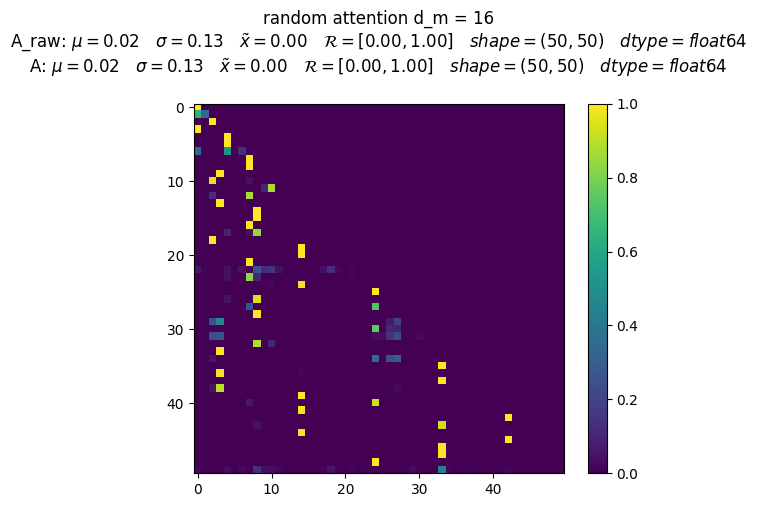

[ <ipykernel>:47 ] A_raw: μ=-0.30 σ=38.29 x̃=-0.08 R=[-216.36,204.48] ℙ=|  ▁█▂  | shape=(50,50) dtype=float64
[ <ipykernel>:49 ] A: μ=0.02 σ=0.14 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(50,50) dtype=float64


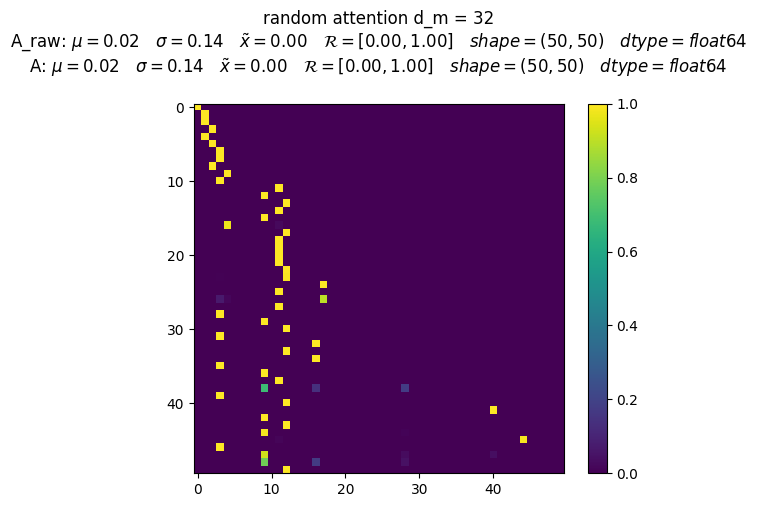

[ <ipykernel>:47 ] A_raw: μ=-1.39 σ=109.88 x̃=0.74 R=[-579.70,826.00] ℙ=|  █▄   | shape=(50,50) dtype=float64
[ <ipykernel>:49 ] A: μ=0.02 σ=0.14 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(50,50) dtype=float64


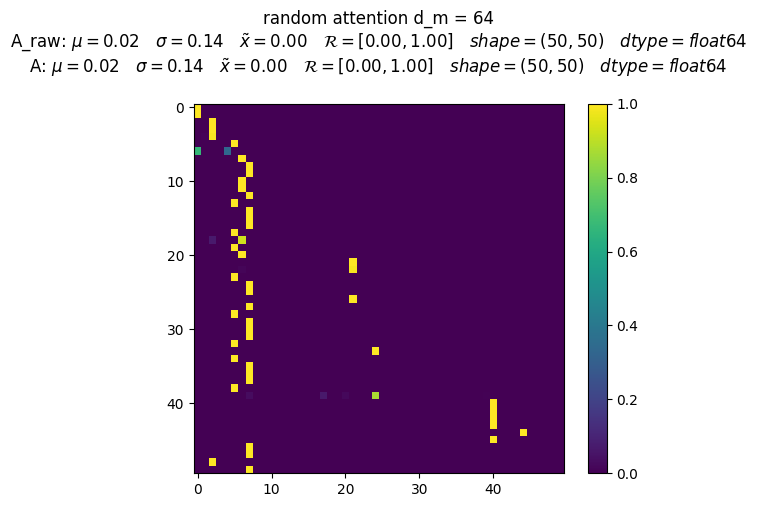

[ <ipykernel>:47 ] A_raw: μ=0.47 σ=203.98 x̃=-0.84 R=[-964.22,1025.75] ℙ=|  ▂█▁  | shape=(50,50) dtype=float64
/tmp/ipykernel_16294/2352395336.py:13: RuntimeWarning: overflow encountered in exp
  A = np.exp(A) / np.sum(np.exp(A), axis=1, keepdims=True)
/tmp/ipykernel_16294/2352395336.py:13: RuntimeWarning: invalid value encountered in divide
  A = np.exp(A) / np.sum(np.exp(A), axis=1, keepdims=True)
[ <ipykernel>:49 ] A: 🚨 NANvals=6 (0.2%) μ=0.02 σ=0.14 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(50,50) dtype=float64


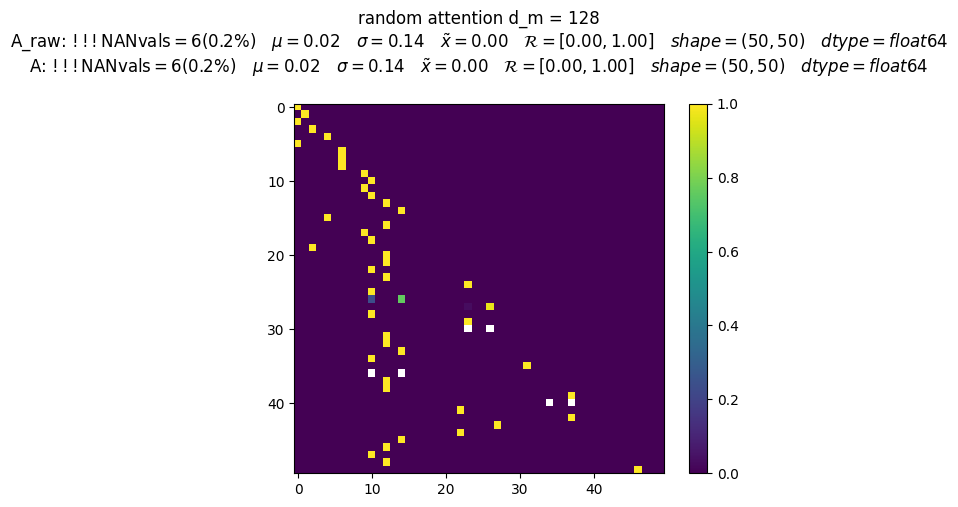

[ <ipykernel>:47 ] A_raw: μ=3.08 σ=413.03 x̃=3.26 R=[-2029.15,2291.56] ℙ=|  ▂█▁  | shape=(50,50) dtype=float64
[ <ipykernel>:49 ] A: 🚨 NANvals=68 (2.7%) μ=0.01 σ=0.10 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(50,50) dtype=float64


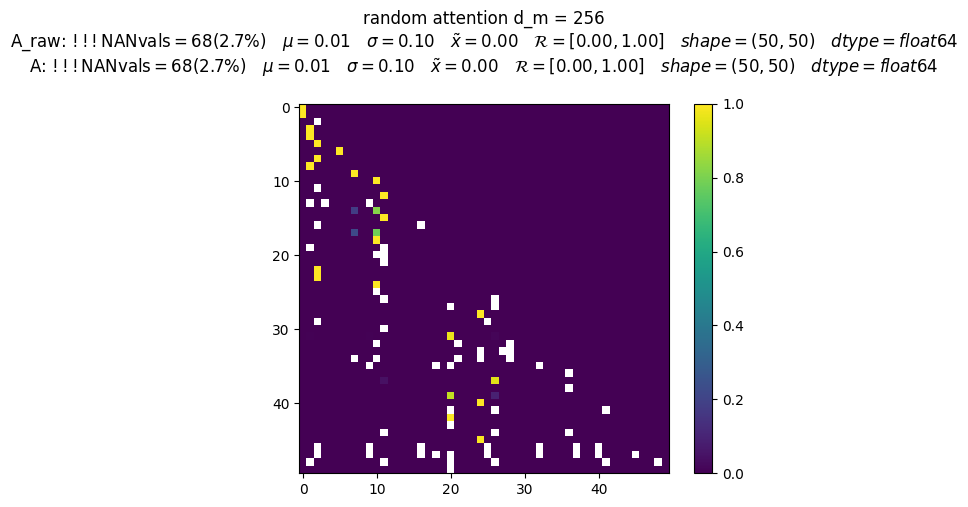

In [ ]:
def mask_and_softmax(
	A: Float[np.ndarray, "n_ctx n_ctx"],
) -> Float[np.ndarray, "n_ctx n_ctx"]:
	n_ctx: int = A.shape[-1]
	A[np.triu_indices(n_ctx, 1)] = -np.inf
	# row wise softmax
	A = np.exp(A) / np.sum(np.exp(A), axis=1, keepdims=True)
	return A


def get_unif_attn(n_ctx: int) -> Float[np.ndarray, "n_ctx n_ctx"]:
	"""Get the random attention (row-uniform) matrix."""
	A = np.ones((n_ctx, n_ctx), dtype=float)
	return mask_and_softmax(A)


def get_rand_attn(
	n_ctx: int,
	d_model: int = 128,
	d_head: int = 16,
	pre_softmax: bool = False,
) -> Float[np.ndarray, "n_ctx n_ctx"]:
	X = np.random.randn(n_ctx, d_model)
	W_q = np.random.randn(d_model, d_head)
	W_k = np.random.randn(d_model, d_head)
	# X = np.random.rand(n_ctx, d_model)
	# W_q = np.random.rand(d_model, d_head)
	# W_k = np.random.rand(d_model, d_head)
	A = X @ W_q @ W_k.T @ X.T
	# return A
	if pre_softmax:
		return A
	else:
		return mask_and_softmax(A)


# plt.imshow(get_unif_attn(50))
# plt.title("uniform attention")
# plt.colorbar()
# plt.show()

for d_m in [1, 2, 4, 8, 16, 32, 64, 128, 256]:
	A_raw = get_rand_attn(50, d_m, 2, pre_softmax=True)
	dbg_tensor(A_raw)
	A = mask_and_softmax(A_raw)
	dbg_tensor(A)
	plt.imshow(A)
	plt.title(
		f"random attention {d_m = }\n"
		f"A_raw: ${array_summary(A, fmt='latex', colored=False)}$\n"
		f"A: ${array_summary(A, fmt='latex', colored=False)}$\n"
	)
	plt.colorbar()
	plt.show()